In [1]:
import numpy as np
import os

import random
import pandas as pd
import math
import matplotlib.pyplot as plt


import astropy.units as u
import matplotlib.ticker as mtick

import astropy.constants as const

In [2]:
import sys
#from general_function import *


In [3]:
binnum = 100
folder = './nestpy_det_eff'
EFFICIENCY_folder = './detector_efficiency'

8.87051251452498e-05 0.0001021231477759838 0 0 0 1
0.0001021231477759838 0.00011757085393429379 0 0 0 0
0.00011757085393429379 0.0001353552646571454 0 0 0 0
0.0001353552646571454 0.00015582984266359796 0 0 0 0
0.00015582984266359796 0.00017940151737777142 0 0 0 0
0.00017940151737777142 0.00020653877259522673 0 0 0 1
0.00020653877259522673 0.00023778095753402068 0 0 0 1
0.00023778095753402068 0.00027374900632629436 0 0 0 0
0.00027374900632629436 0.00031515777899881494 0 0 0 0
0.00031515777899881494 0.0003628302692177684 0 0 0 1
0.0003628302692177684 0.0004177139611747718 0 0 0 0
0.0004177139611747718 0.0004808996607049723 0 0 0 0
0.0004808996607049723 0.0005536431749031163 0 0 0 0
0.0005536431749031163 0.0006373902711169723 0 0 0 0
0.0006373902711169723 0.0007338054113746851 0 0 0 0
0.0007338054113746851 0.0008448048333388383 0 0 0 1
0.0008448048333388383 0.0009725946352666578 0 0 0 0
0.0009725946352666578 0.0011197146219096984 0 0 0 4
0.0011197146219096984 0.0012890887827842422 0 0 0 7

0.300089064874051 0.3435731786622005 0 436 0 436
0.3435731786622005 0.3933583156240346 0 471 0 471
0.3933583156240346 0.45035751938805546 0 531 0 531
0.45035751938805546 0.5156161372808408 0 634 0 634
0.5156161372808408 0.5903309916656097 1 732 1 732
0.5903309916656097 0.675872329284934 3 771 3 771
0.675872329284934 0.773808951151588 20 993 20 993
0.773808951151588 0.8859369838617659 61 1128 61 1128
0.8859369838617659 1.0143128199874303 114 1262 114 1262
1.0143128199874303 1.1612908316641435 328 1503 328 1503
1.1612908316641435 1.3295665490296282 690 1705 690 1705
1.3295665490296282 1.5222260953919287 1113 1919 1113 1919
1.5222260953919287 1.7428027857524893 1751 2240 1751 2240
1.7428027857524893 1.9953419266831047 2313 2526 2313 2526
1.9953419266831047 2.284475005965985 2784 2855 2784 2855
2.284475005965985 2.615504632611329 3322 3340 3322 3340
2.615504632611329 2.994501785025525 3775 3776 3775 3776
2.994501785025525 3.4284171508303967 4245 4246 4245 4246
3.4284171508303967 3.92520860

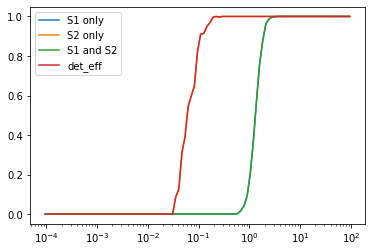

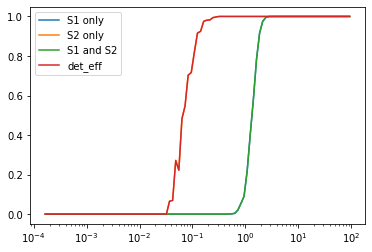

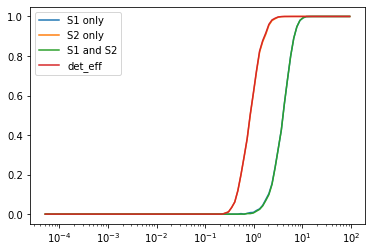

In [8]:
for detector in ['Xe100t_5']:#'LZ', 'G3', 'XENONnT', 'Xe100t_5'
    for interaction in ['beta', 'gammaRay', 'NR']:#
        FILE_NAME = detector+'_S1S2_'+interaction+'_Xenon_1e+06_0-100keV'
        bins_E_centers, bins_E, eff, eff_S1, eff_S2, eff_S1S2 = generate_eff(FILE_NAME, binnum, folder = folder,
                                                             logbin = True, plot_eff = True, 
                                                            s1phe_boundary = [0,0], s2phe_boundary = [0,0])
        df_eff = pd.DataFrame()
        df_eff['E_center [keV]'] = bins_E_centers
        df_eff['E [keV]'] = [str(bins_E[i])+'-'+str(bins_E[i+1]) for i in range(0, len(bins_E)-1)]
        df_eff['trigger eff'] = eff
        df_eff['eff S1'] = eff_S1
        df_eff['eff S2'] = eff_S2
        df_eff['eff S1S2'] = eff_S1S2
        df_eff.to_csv(os.path.join(EFFICIENCY_folder, 'det_eff_'+detector+'_'+interaction+'.csv'))

In [ ]:
def get_efficiency(eff_S1, eff_S2):
    return eff_S1 + (1 - eff_S1)*eff_S2

def generate_eff(file_name, binnum, folder = os.path.join(os.path.join('nestpy', 'tutorials'),'det_eff_sim'),
                 logbin = True, plot_eff = True, s1phe_boundary = [0,0], s2phe_boundary = [0,0]):
    file = os.path.join(folder, file_name+'.txt')
    data = np.array(read_file_dataline(file))
    
    dataf = pd.DataFrame({'E[keV]':data[0],
                      'cS1[phe]':data[1],
                      'cS2[phe]':data[2],
                      'Etrue[keV]':data[3]})
    
    counts, bins = np.histogram(dataf['Etrue[keV]'], binnum, density = True)
    if logbin:
        bins_E = np.logspace(np.log10(min(bins)-min(bins)/10), np.log10(max(bins)+max(bins)/100), binnum)
    else:
        bins_E = bins
    bins_E_centers = (bins_E[1:]+bins_E[:-1])/2
    eff_S1, eff_S2, eff_S1S2 = np.zeros(bins_E_centers.shape), np.zeros(bins_E_centers.shape),np.zeros(bins_E_centers.shape)
    #bins_E,eff_S1,eff_S2
    for b in range(0, len(bins_E)-1):
        good = [E_true >= bins_E[b] and E_true <bins_E[b+1]  for E_true in dataf['Etrue[keV]']]
        if sum(s1phe_boundary)>0 and sum(s2phe_boundary)>0:
            print('ROI: s1phe ', str(s1phe_boundary), ', s2phe', str(s2phe_boundary))
            good_S1 = sum([s1> min(s1phe_boundary) and s1<max(s1phe_boundary) 
                           for s1 in dataf[good]['cS1[phe]']
                          ])
            good_S2 = sum([s2> min(s2phe_boundary) and s2<max(s2phe_boundary) 
                           for s2 in dataf[good]['cS2[phe]']
                          ])
            good_S1S2 = sum([s1> min(s1phe_boundary) and s1<max(s1phe_boundary) and 
                             s2> min(s2phe_boundary) and s2<max(s2phe_boundary)  
                             for s1, s2 in zip(dataf[good]['cS1[phe]'], dataf[good]['cS2[phe]'])
                            ])
        else:
            
            good_S1 = sum(dataf[good]['cS1[phe]'] > 0)
            good_S2 = sum(dataf[good]['cS2[phe]'] > 0)
            good_S1S2 = sum([s1 > 0 and s2 > 0 for s1, s2 in zip(dataf[good]['cS1[phe]'], dataf[good]['cS2[phe]'])])

        if len(dataf[good]) == 0:
            eff_S1[b] = 0
            eff_S2[b] = 0
            eff_S1S2[b] = 0
        else:
            eff_S1[b] = good_S1/len(dataf[good])
            eff_S2[b] = good_S2/len(dataf[good])
            eff_S1S2[b] = good_S1S2/len(dataf[good])

        print(bins_E[b], bins_E[b+1], good_S1, good_S2, good_S1S2, len(dataf[good]))

    eff_S1[np.isnan(eff_S1)] = 0 
    eff_S2[np.isnan(eff_S2)] = 0 
    eff_S1S2[np.isnan(eff_S1S2)] = 0 
    
    if plot_eff:
        fig, ax = plt.subplots()
        ax.plot(bins_E_centers, eff_S1, label = 'S1 only')
        ax.plot(bins_E_centers, eff_S2, label = 'S2 only')
        ax.plot(bins_E_centers, eff_S1S2, label = 'S1 and S2')
        ax.plot(bins_E_centers, get_efficiency(eff_S1, eff_S2), label = 'det_eff')
        ax.set_xscale('log')
        #ax.set_xlim(1e-1, 20)
        ax.legend()
    return bins_E_centers, bins_E, get_efficiency(eff_S1, eff_S2), eff_S1, eff_S2, eff_S1S2